In [1]:
# 1. Reset to root working directory and pull latest code
import os
%cd /kaggle/working

if os.path.exists('fyp-dtcr-unet'):
    !cd fyp-dtcr-unet && git checkout main && git pull origin main
else:
    !git clone https://github.com/shadyOg/fyp-dtcr-unet.git

%cd /kaggle/working/fyp-dtcr-unet/dtcr-unet
!pip install -q -r requirements.txt


/kaggle/working
Cloning into 'fyp-dtcr-unet'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (268/268), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 268 (delta 153), reused 187 (delta 78), pack-reused 0 (from 0)
Receiving objects: 100% (268/268), 2.48 MiB | 9.05 MiB/s, done.
Resolving deltas: 100% (153/153), done.
/kaggle/working/fyp-dtcr-unet/dtcr-unet


In [2]:
import os
from pathlib import Path

print("=== Scanning /kaggle/input ===")
input_root = Path('/kaggle/input')
for d in sorted(input_root.iterdir()):
    n_files = sum(1 for _ in d.rglob('*') if _.is_file())
    print(f"  📁 {d.name}/ ({n_files} files)")

# Auto-detect MosMedData path
MOSMED_PATH = None
for d in input_root.iterdir():
    nii_files = list(d.rglob('study_*.nii*'))
    if nii_files:
        MOSMED_PATH = str(d)
        print(f"\n✅ MosMedData found: {MOSMED_PATH} ({len(nii_files)} NIfTI files)")
        break
if not MOSMED_PATH:
    print("\n⚠️ MosMedData not found in /kaggle/input")

# Auto-detect LIDC-IDRI path
LIDC_PATH = None
for d in input_root.iterdir():
    lidc_dirs = list(d.rglob('LIDC-IDRI-*'))
    if lidc_dirs:
        LIDC_PATH = str(d)
        print(f"✅ LIDC-IDRI found: {LIDC_PATH} ({len(lidc_dirs)} patient/batch folders)")
        break
if not LIDC_PATH:
    for d in input_root.iterdir():
        if list(d.rglob('seg_LIDC-IDRI')):
            LIDC_PATH = str(d)
            print(f"✅ LIDC-IDRI (pre-segmented) found: {LIDC_PATH}")
            break
if not LIDC_PATH:
    print("⚠️ LIDC-IDRI not found in /kaggle/input")

PROCESSED_OUT = "/kaggle/working/data/processed"
print(f"\nTarget output folder: {PROCESSED_OUT}")

# Preprocessing: --context 2 matches paper Section 4.1 (±2 adjacent slices)
cmd = f'python data/preprocessing.py --out {PROCESSED_OUT} --size 256 --context 2 --labeled-ratio 0.4 --max-patients 150'

if MOSMED_PATH:
    cmd += f' --mosmed "{MOSMED_PATH}"'
if LIDC_PATH:
    cmd += f' --lidc "{LIDC_PATH}"'

print(f"Executing: {cmd}\n")
!{cmd}


=== Scanning /kaggle/input ===
  📁 datasets/ (135328 files)

✅ MosMedData found: /kaggle/input/datasets (1160 NIfTI files)
✅ LIDC-IDRI found: /kaggle/input/datasets (601 patient/batch folders)

Target output folder: /kaggle/working/data/processed
Executing: python data/preprocessing.py --out /kaggle/working/data/processed --size 256 --context 2 --labeled-ratio 0.4 --max-patients 150 --mosmed "/kaggle/input/datasets" --lidc "/kaggle/input/datasets"

Found 50 paired MosMed volumes.
Total annotated studies with lesions: 50
Split breakdown: Train=30 studies, Val=10 studies, Test=10 studies.
Processing test split: 100%|████████████████████| 10/10 [00:20<00:00,  2.08s/it]

Preprocessing complete!
{
  "dataset": "MosMedData",
  "target_size": [
    256,
    256
  ],
  "total_extracted_slices": 1148,
  "splits": {
    "train": 721,
    "val": 209,
    "test": 218
  },
  "semi_supervised_breakdown": {
    "train_labeled": 269,
    "train_unlabeled": 452
  },
  "labeled_ratio": 0.4,
  "seed": 42

In [3]:
import os
for split in ["train", "val", "test"]:
    img_dir = f"{PROCESSED_OUT}/{split}/images"
    mask_dir = f"{PROCESSED_OUT}/{split}/masks"
    lsf_dir = f"{PROCESSED_OUT}/{split}/level_sets"
    n_imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_masks = len(os.listdir(mask_dir)) if os.path.exists(mask_dir) else 0
    n_lsfs = len(os.listdir(lsf_dir)) if os.path.exists(lsf_dir) else 0
    print(f"Split [{split:>5}]: {n_imgs:>4} images | {n_masks:>4} masks | {n_lsfs:>4} level-set maps")


Split [train]: 2317 images | 2317 masks | 2317 level-set maps
Split [  val]:  805 images |  805 masks |  805 level-set maps
Split [ test]:  704 images |  704 masks |  704 level-set maps


In [4]:
# batch-size 8 * grad-accum 4 = 32 effective batch size (Paper Section 4.2)
# lr 0.001 matches paper with AdamW & Cosine Annealing
!python train.py \
    --data /kaggle/working/data/processed \
    --epochs 80 \
    --batch-size 8 \
    --grad-accum 4 \
    --lr 0.001 \
    --labeled-ratio 0.4 \
    --checkpoints /kaggle/working/checkpoints \
    --outputs /kaggle/working/outputs


Using device: cuda | AMP Mixed Precision: True | Filter Empty Val Slices: True
Data ready: 2317 train samples, 490 val samples.

Starting DTCR-U-Net training for 80 epochs...

Epoch 1/80 [Train]: 100%|█| 255/255 [01:50<00:00,  2.30it/s, Loss=1.8470, Seg=1.
Epoch 01/80 (120.2s) | LR: 2.80e-04 | Train Loss: 2.0454 | Val Loss: 1.7124 | Val Dice: 0.00% (Lesion: 0.00%) | Val SE: 0.00% | Val SP: 99.47% | Val Acc: 99.23% | Val F1: 0.00% | Val HD: 233.10px | Skipped: 1 batches
Epoch 2/80 [Train]: 100%|█| 255/255 [01:53<00:00,  2.25it/s, Loss=1.4453, Seg=1.
Epoch 02/80 (122.9s) | LR: 4.60e-04 | Train Loss: 1.6003 | Val Loss: 1.6526 | Val Dice: 0.00% (Lesion: 0.00%) | Val SE: 0.00% | Val SP: 99.33% | Val Acc: 99.09% | Val F1: 0.00% | Val HD: 224.39px
Epoch 3/80 [Train]: 100%|█| 255/255 [01:52<00:00,  2.26it/s, Loss=1.3812, Seg=1.
Epoch 03/80 (122.4s) | LR: 6.40e-04 | Train Loss: 1.4323 | Val Loss: 1.4083 | Val Dice: 0.96% (Lesion: 0.96%) | Val SE: 0.55% | Val SP: 99.85% | Val Acc: 99.62% | Val F

In [5]:
!python evaluate.py \
    --checkpoint /kaggle/working/checkpoints/best_model.pth \
    --data /kaggle/working/data/processed \
    --batch-size 8 \
    --save-vis 20 \
    --out /kaggle/working/evaluation_results


Loading checkpoint from: /kaggle/working/checkpoints/best_model.pth
Test samples: 704
Testing: 100%|██████████████████████████████████| 88/88 [00:50<00:00,  1.76it/s]

      PATIENT-LEVEL 3D EVALUATION (Paper Protocol Table 2)
  DICE           : 42.00% ± 26.00%
  SENSITIVITY    : 56.62% ± 29.74%
  SPECIFICITY    : 99.96% ± 0.04%
  ACCURACY       : 99.93% ± 0.07%
  F1             : 42.00% ± 26.00%

      LESION-ONLY SLICE EVALUATION (Excl. Empty Slices)
  DICE           : 42.25 ± 36.24
  SENSITIVITY    : 49.50 ± 41.69
  SPECIFICITY    : 99.95 ± 0.08
  ACCURACY       : 99.88 ± 0.16
  F1             : 42.25 ± 36.24
  HD             : 107.74 ± 132.00

      RAW 2D SLICE EVALUATION (All Slices)
  DICE           : 48.86 ± 42.98
  SENSITIVITY    : 70.81 ± 40.33
  SPECIFICITY    : 99.96 ± 0.07
  ACCURACY       : 99.92 ± 0.14
  F1             : 48.86 ± 42.98
  HD             : 126.57 ± 155.04


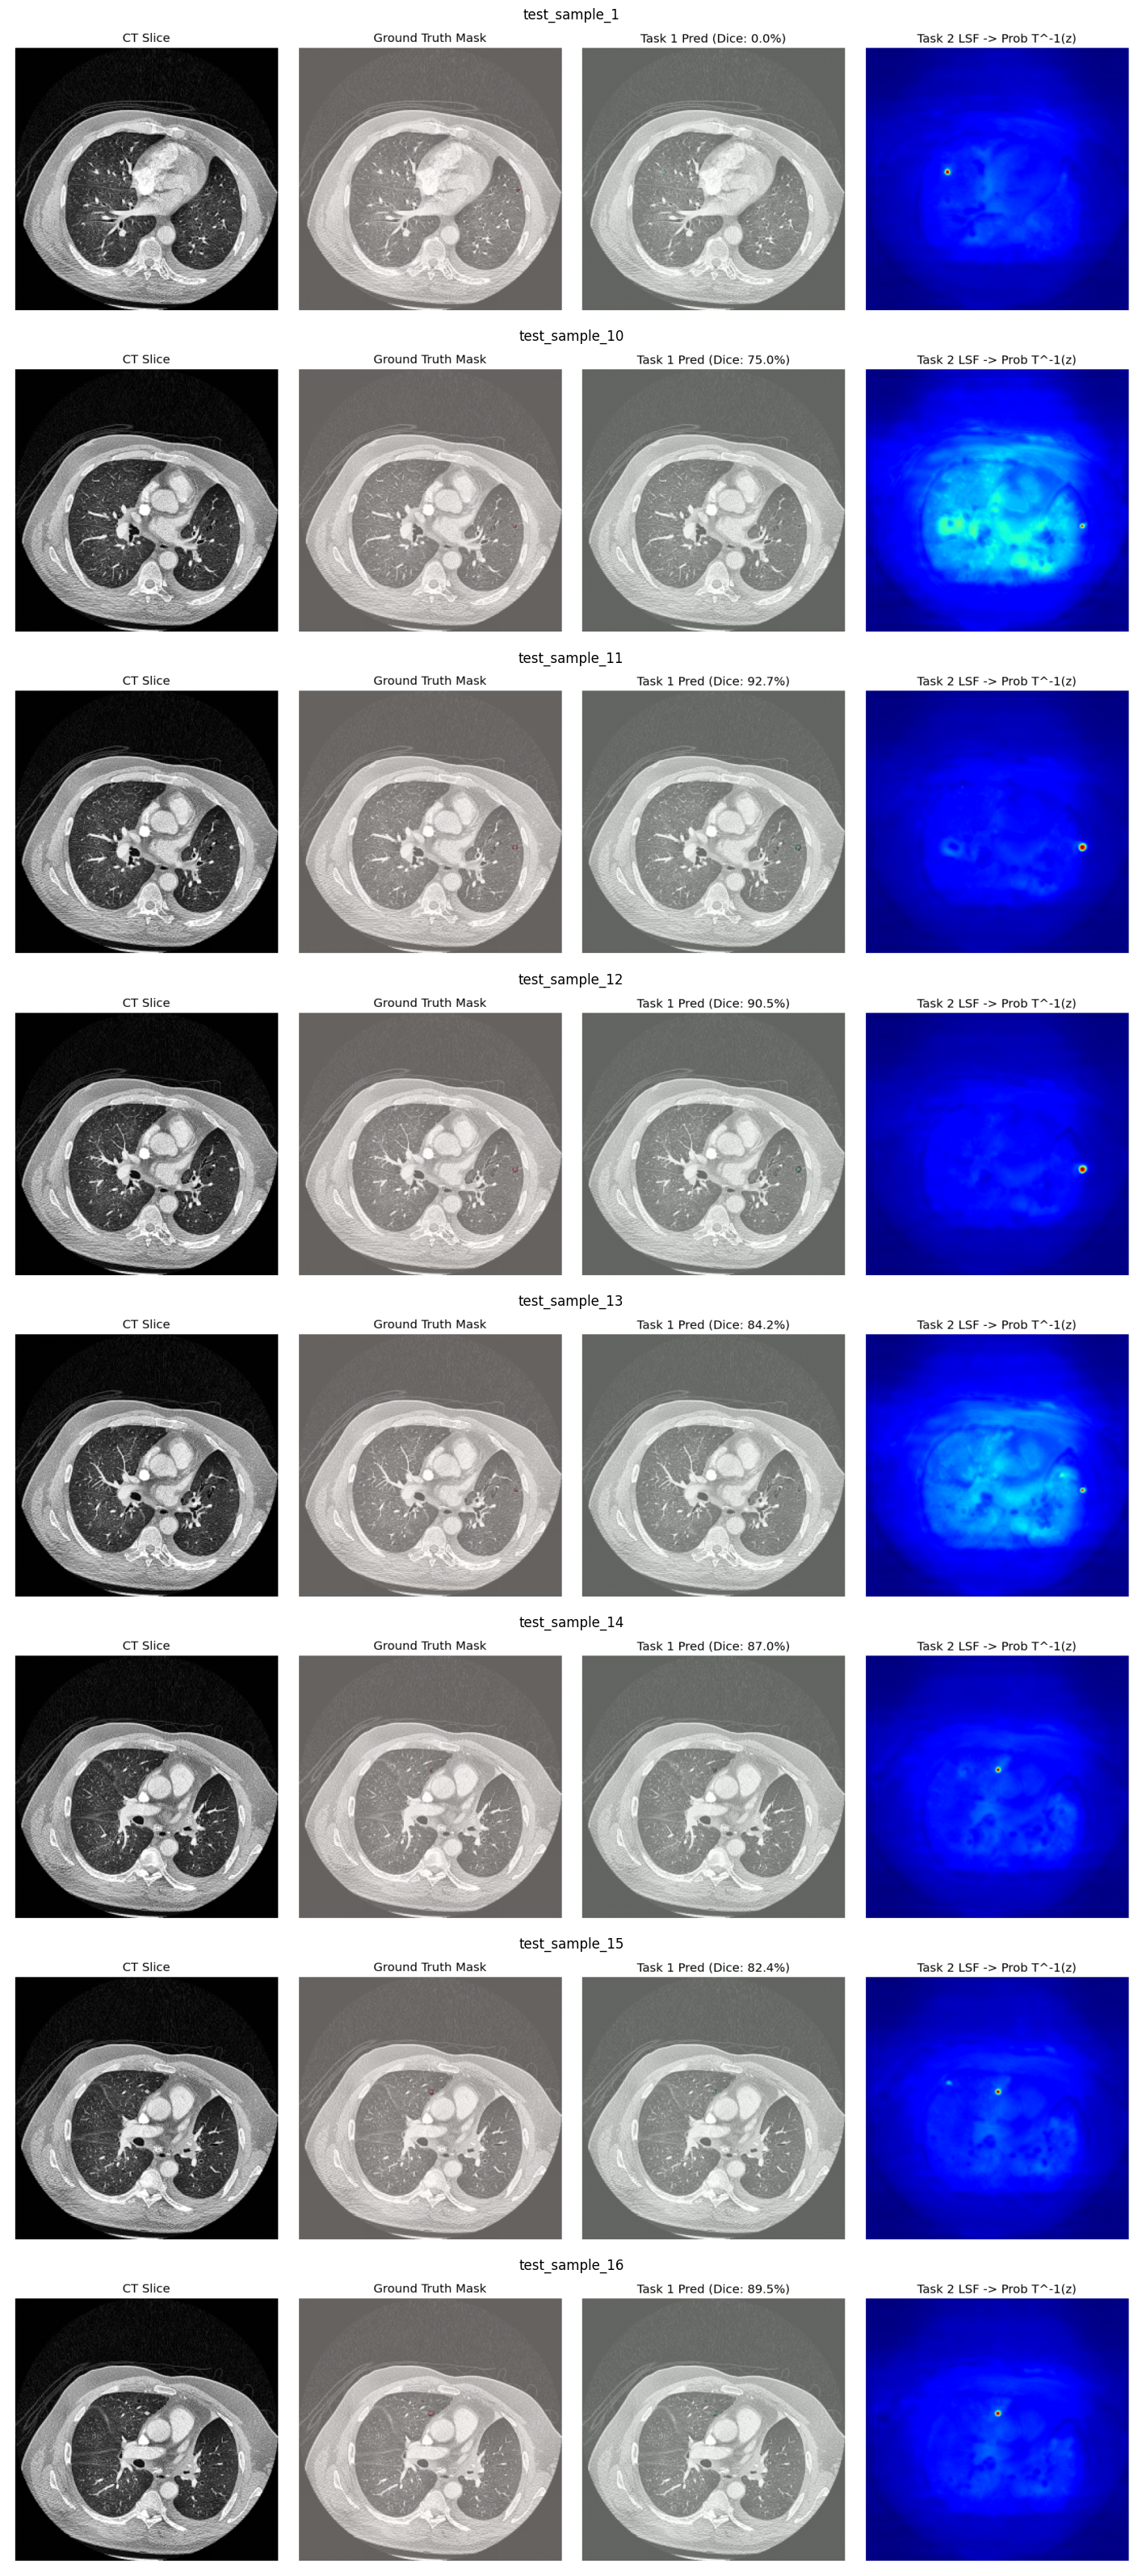

In [6]:
import glob
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

viz_files = sorted(glob.glob('/kaggle/working/evaluation_results/comparisons/*.png'))[:8]
if viz_files:
    plt.figure(figsize=(16, 4 * len(viz_files)))
    for i, f in enumerate(viz_files):
        plt.subplot(len(viz_files), 1, i + 1)
        plt.imshow(Image.open(f))
        plt.axis('off')
        plt.title(Path(f).stem, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No comparison images found. Check /kaggle/working/evaluation_results/")
